In [22]:
# %%
import pandas as pd

dataset = pd.read_csv("../data/auto_mpg.csv")
dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [23]:
# %%
# Tamaño del dataset

dataset.shape


(398, 8)

In [24]:

# %%
# Búsqueda de valores nulos

dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [13]:
# %%
# Remoción de valores nulos

dataset = dataset.dropna()
dataset.isna().sum()


MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [25]:
# %%
# Columna Origin
# Nota:  1) USA
#        2) Europe
#        3) Japan

dataset.Origin.value_counts()

Origin
1    249
3     79
2     70
Name: count, dtype: int64

In [26]:
# %%

# Convierte la columna a categorias.
# Nota. Realmente no se debería hacer asi para aplicaciones
# en productivo

dataset["Origin"] = dataset["Origin"].map(
    {   
        1: "USA", 
        2: "Europe", 
        3: "Japan",
    },
)
dataset.head(20)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,USA
1,15.0,8,350.0,165.0,3693.0,11.5,70,USA
2,18.0,8,318.0,150.0,3436.0,11.0,70,USA
3,16.0,8,304.0,150.0,3433.0,12.0,70,USA
4,17.0,8,302.0,140.0,3449.0,10.5,70,USA
5,15.0,8,429.0,198.0,4341.0,10.0,70,USA
6,14.0,8,454.0,220.0,4354.0,9.0,70,USA
7,14.0,8,440.0,215.0,4312.0,8.5,70,USA
8,14.0,8,455.0,225.0,4425.0,10.0,70,USA
9,15.0,8,390.0,190.0,3850.0,8.5,70,USA


In [27]:
# %%
# Genera variables dummy para indicar la procedencia (Pésima solución)

dataset = pd.get_dummies(dataset, columns=["Origin"], prefix="", prefix_sep="")
dataset.head(20)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693.0,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436.0,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433.0,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449.0,10.5,70,False,False,True
5,15.0,8,429.0,198.0,4341.0,10.0,70,False,False,True
6,14.0,8,454.0,220.0,4354.0,9.0,70,False,False,True
7,14.0,8,440.0,215.0,4312.0,8.5,70,False,False,True
8,14.0,8,455.0,225.0,4425.0,10.0,70,False,False,True
9,15.0,8,390.0,190.0,3850.0,8.5,70,False,False,True


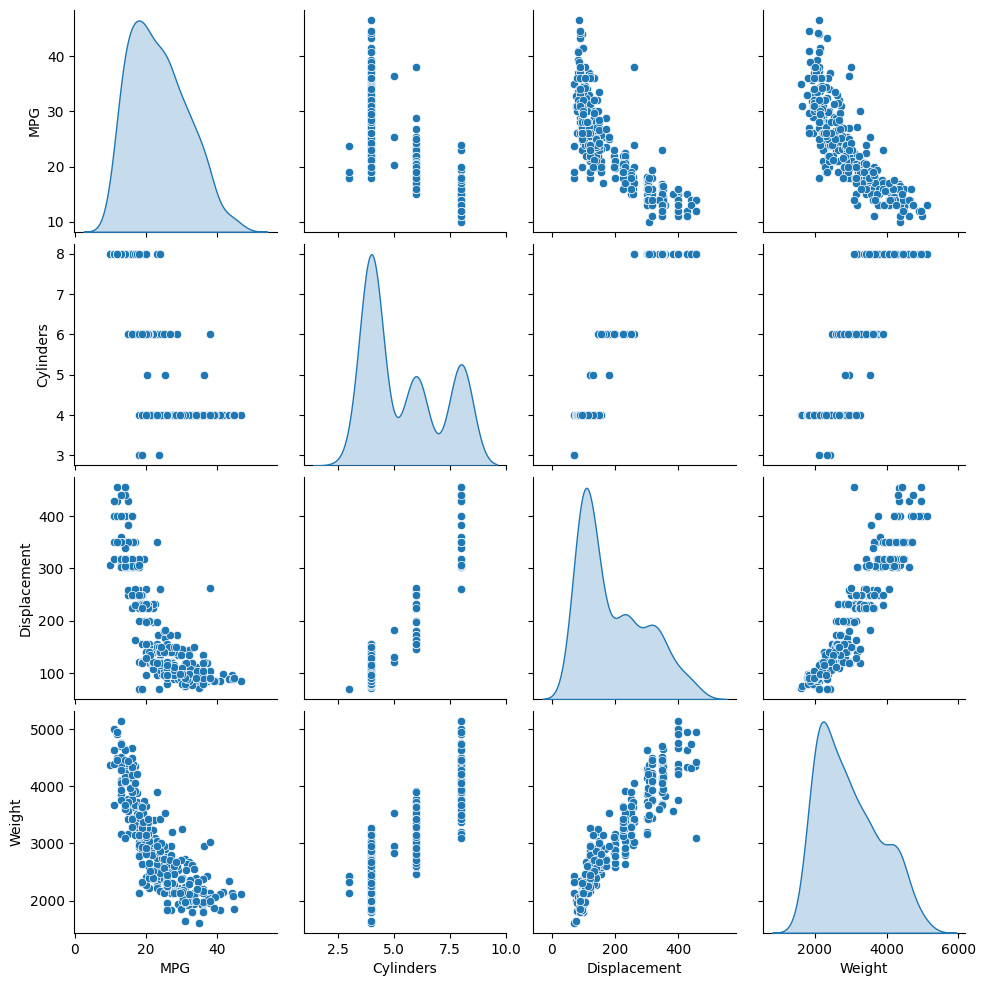

In [30]:
# Note que aca no se usa train_test_split

train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

c:\Users\ESTEBAN\Documents\GitHub\std-esteban-medina-guayasamin2\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ESTEBAN\Documents\GitHub\std-esteban-medina-guayasamin2\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ESTEBAN\Documents\GitHub\std-esteban-medina-guayasamin2\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ESTEBAN\Documents\GitHub\std-esteban-medina-guayasamin2

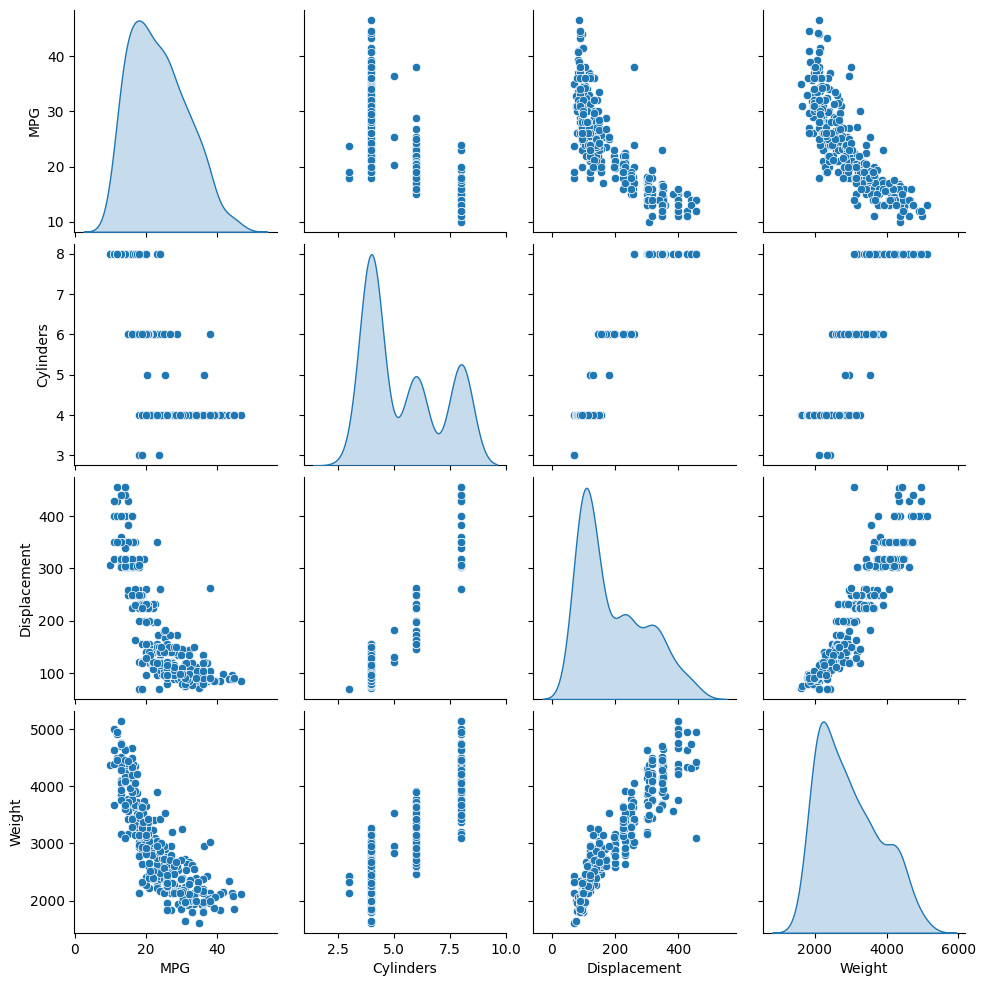

In [31]:
# Las millas por galon (MPG) son función de las demas variables.

import seaborn as sns

sns.pairplot(
    train_dataset[["MPG", "Cylinders", "Displacement", "Weight"]], diag_kind="kde"
)


In [32]:
# %%

# Cálculo de algunas estadísticas generales

train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,318.0,23.590566,7.913617,10.0,17.125,22.75,29.00,46.6
Cylinders,318.0,5.427673,1.682941,3.0,4.000,4.00,6.00,8.0
Displacement,318.0,193.061321,103.812742,70.0,100.250,151.00,259.50,455.0
Horsepower,313.0,104.067093,38.674662,46.0,75.000,92.00,120.00,230.0
Weight,318.0,2963.823899,844.749805,1613.0,2219.250,2792.50,3571.25,5140.0
Acceleration,318.0,15.595912,2.796282,8.0,13.900,15.50,17.30,24.8
Model Year,318.0,75.946541,3.705266,70.0,73.000,76.00,79.00,82.0


In [33]:
# %%
# Particionamiento de los datos en features y labels

train_features = train_dataset.copy()
train_labels = train_features.pop("MPG")

test_features = test_dataset.copy()
test_labels = test_features.pop("MPG")

In [48]:
# %%
# Estandarización de los datos (normalización)

train_dataset.describe().transpose()[["mean", "std"]]




# Efecto del StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

pd.DataFrame(
    data=scaler.fit_transform(train_dataset),
    columns=train_dataset.columns,
).describe().transpose()[["mean", "std"]]

,mean,std
MPG,2.346132e-16,1.001576
Cylinders,8.379042e-18,1.001576
Displacement,7.261836e-17,1.001576
Horsepower,-1.135052e-16,1.001601
Weight,-1.256856e-16,1.001576
Acceleration,-5.865329e-17,1.001576
Model Year,-1.509624e-15,1.001576
Europe,5.865329e-17,1.001576
Japan,4.049870e-17,1.001576
USA,8.379042e-17,1.001576


In [50]:
  # %%
  # Regresión lineal con una sola variable (Horsepower)

horsepower_scaler = StandardScaler()

train_horsepower = train_features[["Horsepower"]]
test_horsepower = test_features[["Horsepower"]]

horsepower_scaler.fit(train_horsepower)

standarized_train_horsepower = horsepower_scaler.transform(train_horsepower)
standarized_test_horsepower = horsepower_scaler.transform(test_horsepower)







# %%
# Modelo de regresión lineal

from sklearn.linear_model import LinearRegression

horsepower_model = LinearRegression()
horsepower_model.fit(standarized_train_horsepower, train_labels)






# %%

# Intercepto
horsepower_model.intercept_





# Coeficientes
horsepower_model.coef_





# %%
import numpy as np

x = pd.DataFrame({"Horsepower": np.linspace(0, 250, 251)})
x.head()




# %%
# Predicción

scaled_x = horsepower_scaler.transform(x)
y = horsepower_model.predict(scaled_x)
y[:5]





# %%
import matplotlib.pyplot as plt


def plot_horsepower(x, y):
    plt.scatter(train_features["Horsepower"], train_labels, label="Data")
    plt.plot(x, y, color="k", label="Predictions")
    plt.xlabel("Horsepower")
    plt.ylabel("MPG")
    plt.legend()

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values